# Regresion Lineal: Coste de incidente de seguridad
En este ejercicio se explicaran los fundamentos basicos de la regresion lineal aplicada a un caso de uso sencillo relacionado con la ciberseguridad

# Enunciado del ejercicio
Este ejercicio consiste en predecir el costo de un incidente de seguridad en base al numero de equipos que se han visto afectados. El conjunto de datos es generado de manera aleatoria


Realizar Importaciones

In [ ]:
!pip

### Generacion del conjunto de datos

In [1]:
import numpy as np
#conjunto de valoresaleatorios
#x son las computadoras
x = 2 * np.random.rand(100,1)
#y simula el costo por incidente de cada computadora
y = 4 + 3 * x + np.random.rand(100,1)

print("La longitud del conjunto de datos:",len(x))

La longitud del conjunto de datos: 100


### Visualizacion del conjunto de datos


In [2]:
import matplotlib.pyplot as plt
%matplotlib inline


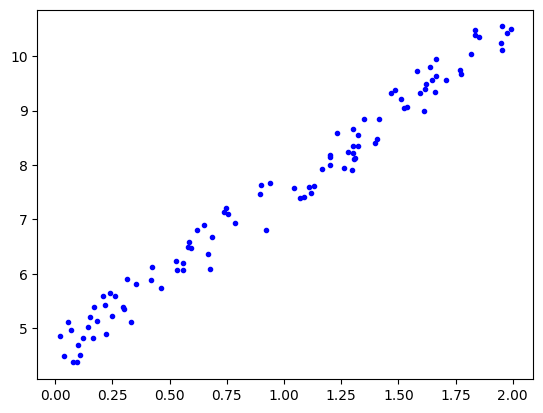

In [3]:
plt.plot(x,y,"b.")
plt.show()

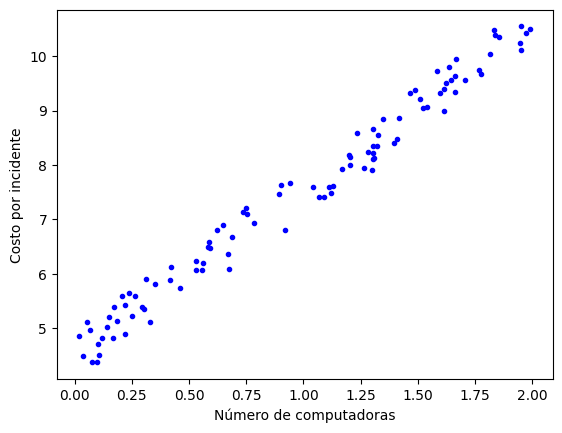

In [4]:
plt.plot(x,y,"b.")
plt.xlabel("Número de computadoras")
plt.ylabel("Costo por incidente")
plt.show()

# Modificacion del conjunto de datos

In [5]:
import pandas as pd

In [6]:
import numpy as np

x = 2 * np.random.rand(100,1)
y = 4 + 3 * x + np.random.rand(100,1)

data = {'n_equipos_afectados': x.flatten(), 'costo': y.flatten()}
df = pd.DataFrame(data)
df.head(10)

,n_equipos_afectados,costo
0,0.901682,6.879448
1,0.217147,5.349103
2,1.844164,10.465623
3,1.570044,9.169123
4,0.909636,7.443179
5,0.765234,7.216289
6,1.560102,9.542595
7,1.308492,8.054976
8,0.727138,6.820262
9,0.504722,6.466461


In [7]:
#Escalado del numero de equipos afectados a un valor mas real
df['n_equipos_afectados'] = df['n_equipos_afectados'] * 1000

df['n_equipos_afectados']=df['n_equipos_afectados'].astype('int')

#Escalado del costo a un valor mas real
df['costo']=df['costo']*10000
df['costo']=df['costo'].astype('int')

#imprime los primeros 10 registros del dataframe
df.head(10)

,n_equipos_afectados,costo
0,901,68794
1,217,53491
2,1844,104656
3,1570,91691
4,909,74431
5,765,72162
6,1560,95425
7,1308,80549
8,727,68202
9,504,64664


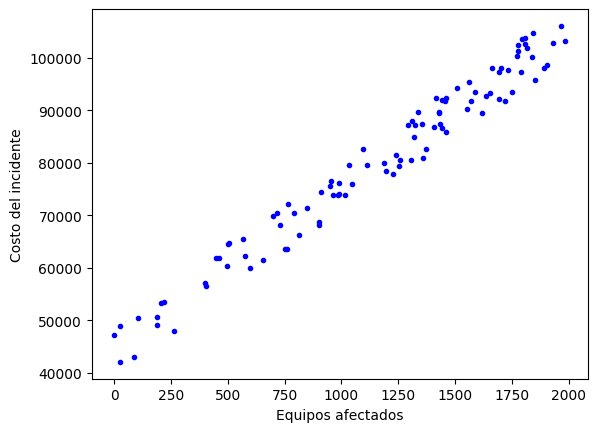

In [8]:
#Representacion grafica del conjunto de datos
plt.plot(df['n_equipos_afectados'], df['costo'], "b.")
plt.xlabel("Equipos afectados")
plt.ylabel("Costo del incidente")
plt.show()

## Construccion del modelo

In [10]:
from sklearn.linear_model import LinearRegression

In [12]:
#carga de modelo y ajuste de la funcion hipotesis 
lin_reg = LinearRegression()
lin_reg.fit(df['n_equipos_afectados'].values.reshape(-1,1),df['costo'].values.reshape(-1,1))

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


In [13]:
#Muestra el valor que le asignamos al parametro theta0(lugar donde cortara el modelo con el eje y tambien conocido como bias)
lin_reg.intercept_


array([45434.23352623])

In [14]:
#Muestra el valor que se le asigno al parametro theta1 (pendiente de la recta)
lin_reg.coef_

array([[29.94760998]])

### Prediccion para el valor minimo y maximo de los datos de entrenamiento

In [15]:
x_min_max= np.array([[df['n_equipos_afectados'].min()],[df['n_equipos_afectados'].max()]])
#prediccion para el entrenamiento
y_train_pred = lin_reg.predict(x_min_max)

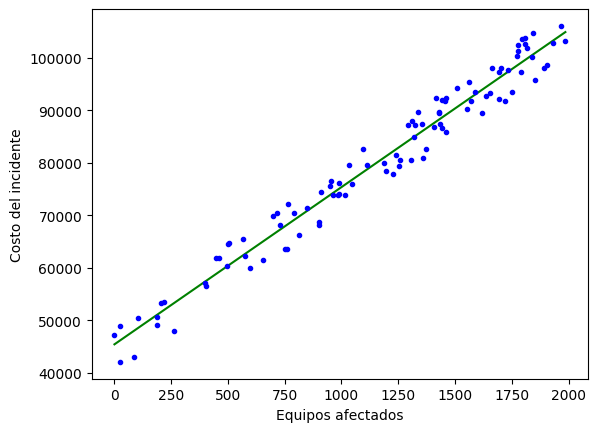

In [16]:
#Representacion grafica de la funcion de hipotesis generada
#eje horizontal el numero de equipos afectados 
plt.plot(x_min_max, y_train_pred, "g-")
#eje vertical el costo del incidente
#funcion hipotesis generada por el modelo
plt.plot(df['n_equipos_afectados'], df['costo'], "b.")
plt.xlabel("Equipos afectados") 
plt.ylabel("Costo del incidente")
plt.show()

### Prediccion de nuevos ejemplos

In [21]:
x_new = np.array([[760]]) #valor de 760 equipos afectados
#prediccion del costo del incidente para 760 equipos afectados
costo=lin_reg.predict(x_new)
print("El costo del incidente seria:", int(costo[0][0]),"$")

El costo del incidente seria: 68194 $


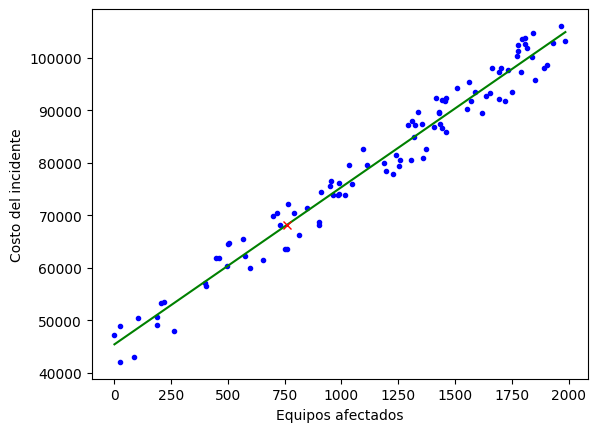

In [22]:
plt.plot(df['n_equipos_afectados'], df['costo'], "b.")

plt.plot(x_min_max, y_train_pred, "g-")
plt.plot(x_new, costo, "rx")
plt.xlabel("Equipos afectados") 
plt.ylabel("Costo del incidente")
plt.show()